In [9]:
# вычисление и визуализация
# электрического потенциала,
# создаваемого линейной системой
# электрических зарядов

# Ячейка № 1
# подключение библиотеки numpy
import numpy as np

# подключение используемых
# графических библиотек и методов
import matplotlib.pyplot as plt
from matplotlib import cm, colors
from matplotlib.colors import LightSource


In [10]:
# Ячейка № 2

# задание функции, возвращающей
# значения потенциала,
# вычисляемые в узлах
# используемой координатной сетки
# в соответствие с (5.4)
def Potential(q, xq, yq, X, Y):
    # q - вектор, содержащий значения электрических зарядов
    # xq, yq - векторы, содержащие x-е и y-е координаты
    # точек, в которых расположены заряды
    # X, Y - матрицы, содержащие координаты узлов сетки,
    # используемой для расчета потенциала электрического поля,
    # значения элементов которых функцией meshgrid

    # определение числа электрических зарядов
    Nq = len(q)

    # определение числа узлов координатной сетки
    # по оси абсцисс
    Nx = len(X)

    # определение числа узлов координатной сетки
    # по оси ординат
    Ny = len(Y)

    # инициализация массива M,
    # используемого для хранения значений потенциала,
    # вычисляемых в соответствие с (5.4)
    M = np.zeros([Nx, Ny])

    # вычисление значений потенциала,
    # вычисляемых в соответствие с (5.4)
    for i in range(Nx):
        for j in range(Ny):
            s = 0
            for k in range(Nq):
                # вычисление модуля радиуса-вектора,
                # начало которого находится
                #  в месте положения k-го заряда,
                # конец - в i,j-том узле
                # используемой координатной сетки
                R = np.sqrt((X[i, j] - xq[k]) ** 2 + (Y[i, j] - yq[k]) ** 2)

                # вычисление потенциала
                # электрического поля
                # в соответствие с (5.4)
                s = s + q[k] / R

            # сохранение значения потенциала
            # электрического поля в i,j-ом
            # узле координатной стеки в матрицу M
            M[i, j] = s

    return M

In [11]:
# Ячейка # 3

# задание числа электрических зарядов
Nq = 49

# задание значений
# электрических зарядов
q = np.ones(Nq)

# задание координаты
# крайне левого заряда
x1 = -5.0

# задание координаты
# крайне правого заряда
x2 = 5.0

# вычисление абсцисс
# радиусов-векторов
# электрических зарядов
xq = np.linspace(x1, x2, Nq, endpoint=False)

# задание ординат
# электрических зарядов
yq = np.zeros(Nq)

# задание числа узлов сетки,
# в узлах которой вычисляются
# значения потенциала,
# создаваемого линейной системой
# электрических зарядов
Nd = 79

# задание минимального значения
# абсциссы координатной сетки
X_min = -10

# задание максимального значения
# абсциссы координатной сетки
X_max = 10

# задание минимального значения
# ординаты координатной сетки
Y_min = -10

# задание максимального значения
# ординаты координатной сетки
Y_max = 10

X = np.linspace(X_min, X_max, Nd, endpoint=False)
Y = np.linspace(Y_min, Y_max, Nd, endpoint=False)

# вычисление значений
# электростатического потенциала,
# создаваемого линейной системой
# электрических зарядов,
# в узлах выбранной сетки
[X1, Y1] = np.meshgrid(X, Y)
M = Potential(q, xq, yq, X1, Y1)


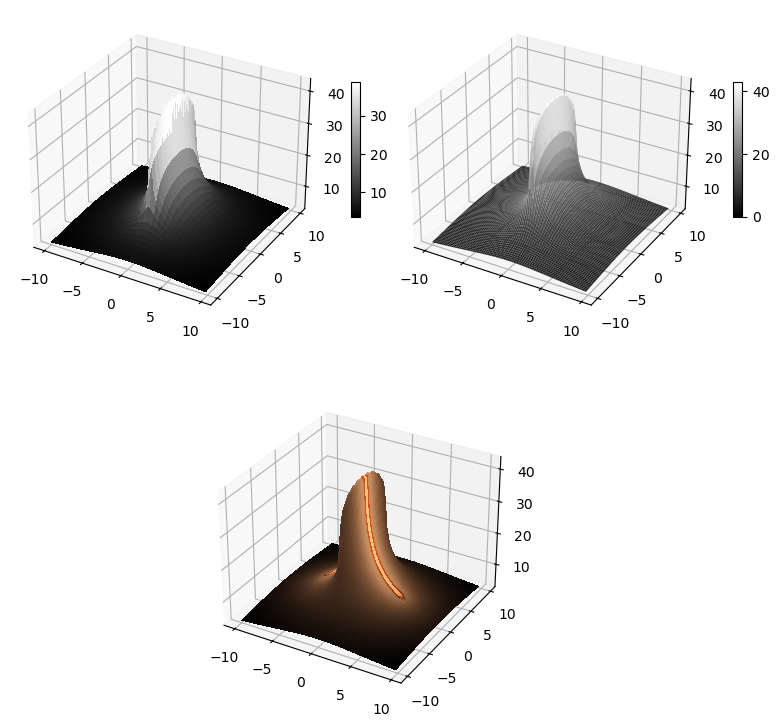

-----------------------------------------


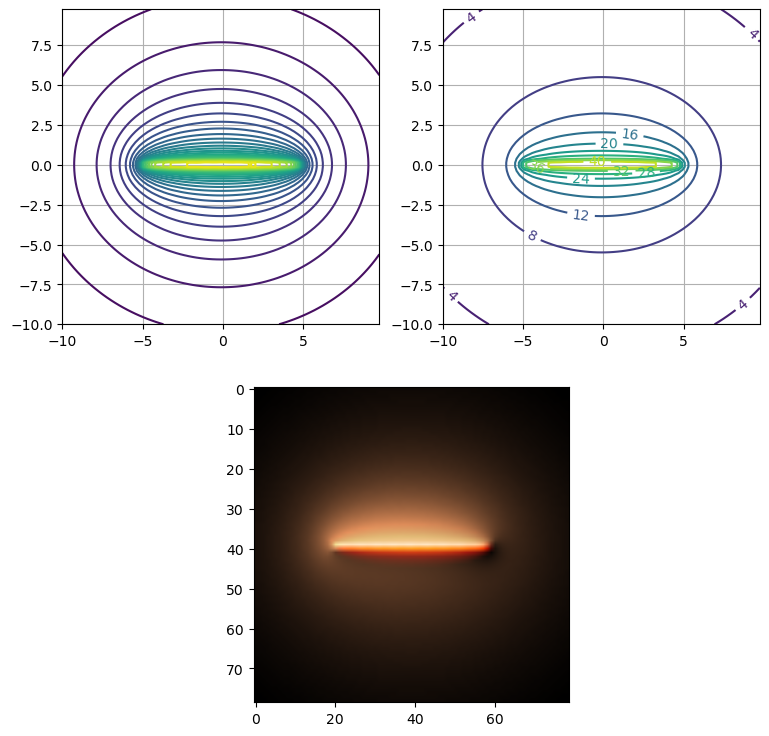

-----------------------------------------


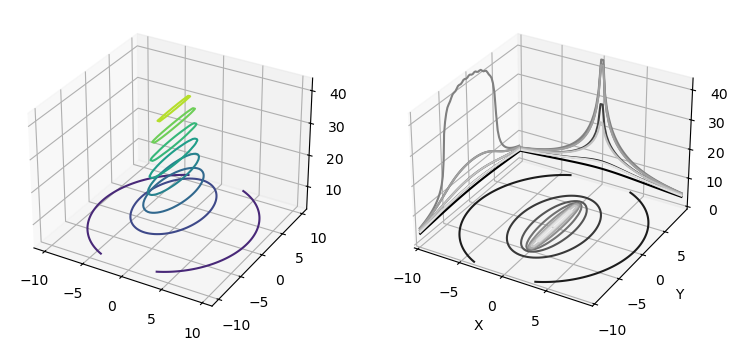

In [12]:
# Ячейка № 4

# визуализация электростатического потенциала
# в виде 3D поверхности
fig = plt.figure(figsize=(9, 9))
ax = fig.add_subplot(2, 1, 2, projection="3d")
ls = LightSource(350, 90)
rgb = ls.shade(M, cmap=cm.copper, vert_exag=0.1, blend_mode="soft")
surf = ax.plot_surface(
    X1,
    Y1,
    M.T,
    rstride=1,
    cstride=1,
    cmap=cm.copper,
    facecolors=rgb,
    linewidth=0,
    antialiased=False,
    shade=False,
)

ax = fig.add_subplot(2, 2, 1, projection="3d")
surf = ax.plot_surface(X1, Y1, M.T, cmap=cm.gray, linewidth=0, antialiased=False)
cax = fig.add_axes([0.505, 0.65, 0.01, 0.15])
fig.colorbar(surf, orientation="vertical", cax=cax)

ax = fig.add_subplot(2, 2, 2, projection="3d")
ls = LightSource(270, 90)  # (270, 45)
norm = colors.Normalize(vmin=0, vmax=np.max(M))
surf = ax.plot_surface(
    X1, Y1, M.T, rstride=1, norm=norm, cstride=1, alpha=1, cmap=cm.gray, linewidth=0
)
cax = fig.add_axes([0.93, 0.65, 0.01, 0.15])
fig.colorbar(surf, orientation="vertical", cax=cax)

plt.show()

print("-----------------------------------------")

# визуализация электростатического потенциала
# в виде 2D карты линий уровня
fig = plt.figure(figsize=(9, 9))
ax = fig.add_subplot(2, 1, 2)
cmap = plt.cm.copper
ls = LightSource(315, 45)
rgb = ls.shade(M, cmap)
# plt.subplots()
ax.imshow(rgb, interpolation="bilinear")
im = ax.imshow(M.T, cmap=cmap)
im.remove()

ax = fig.add_subplot(2, 2, 1)
CS = ax.contour(X1, Y1, M, levels=33)
ax.grid(True)

ax = fig.add_subplot(2, 2, 2)
CS = ax.contour(X1, Y1, M, levels=9)
ax.clabel(CS, inline=True, fontsize=10)
ax.grid(True)

plt.show()
print("-----------------------------------------")

# визуализация электростатического потенциала
# в виде 3D карты линий уровня
fig = plt.figure(figsize=(9, 9))
ax_3d = fig.add_subplot(1, 2, 1, projection="3d")
ax_3d.contour(X1, Y1, M.T, levels=7)
ax = fig.add_subplot(1, 2, 2, projection="3d")
x_min = np.min(X1)
x_max = np.max(X1)
y_min = np.min(Y1)
y_max = np.max(Y1)
z_min = 0
z_max = np.max(M)
ax.contour(X1, Y1, M.T, zdir="z", offset=z_min, cmap="gray")
ax.contour(X1, Y1, M.T, zdir="x", offset=x_min, cmap="gray")
ax.contour(X1, Y1, M.T, zdir="y", offset=y_max, cmap="gray")
ax.set(
    xlim=(x_min, x_max),
    ylim=(y_min, y_max),
    zlim=(z_min, z_max),
    xlabel="X",
    ylabel="Y",
    zlabel="Z",
)

plt.show()